In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\returns_computed.csv")

In [5]:
var_cvar_list = []

for fund in df["amfi_code"].unique():

    returns = df[
        df["amfi_code"] == fund
    ]["daily_return"].dropna()

    # 95% VaR
    var_95 = returns.quantile(0.05)

    # 95% CVaR
    cvar_95 = returns[
        returns <= var_95
    ].mean()

    var_cvar_list.append(
        [
            fund,
            var_95,
            cvar_95
        ]
    )

var_cvar_report = pd.DataFrame(
    var_cvar_list,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_cvar_report.head()


# var_cvar_report.to_csv(
#     "../reports/var_cvar_report.csv",
#     index=False
# )

# print("Saved Successfully")

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [6]:
top_5_funds = [
    120505,
    119598,
    149324,
    100033,
    120843
]

df["date"] = pd.to_datetime(df["date"])

In [7]:

rolling_sharpe_df = pd.DataFrame()

for fund in top_5_funds:

    fund_data = df[
        df["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["rolling_sharpe"] = (
        fund_data["daily_return"]
        .rolling(90)
        .mean()
        /
        fund_data["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_sharpe_df = pd.concat(
        [rolling_sharpe_df, fund_data]
    )

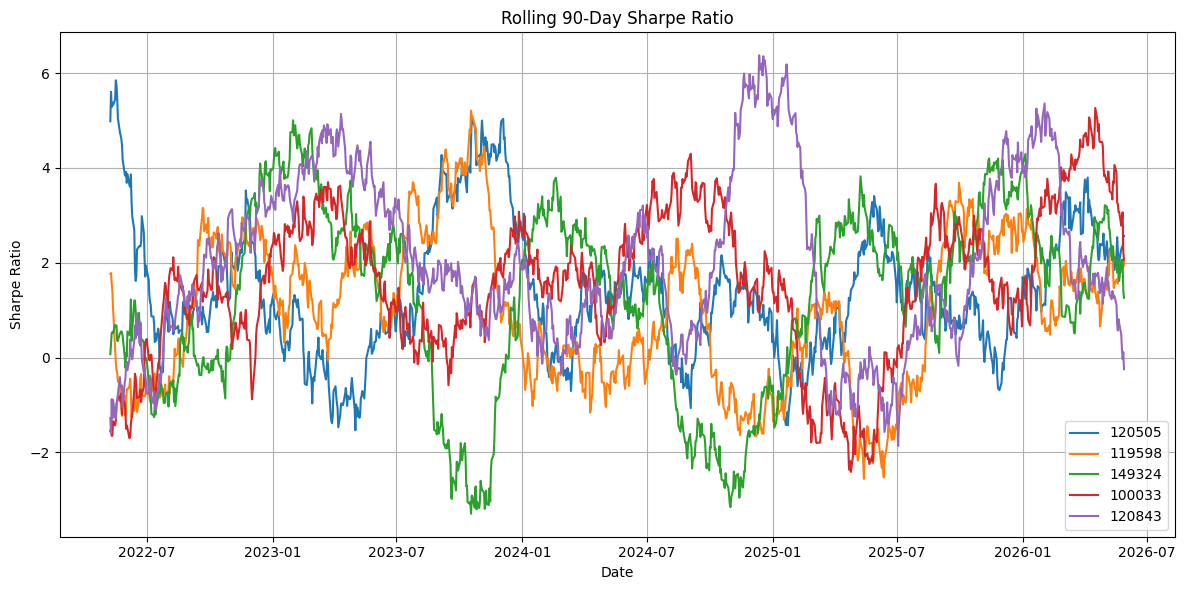

In [15]:
plt.figure(figsize=(12,6))

for fund in top_5_funds:

    plot_data = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        plot_data["date"],
        plot_data["rolling_sharpe"],
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [16]:
transactions = pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\clean_investor_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [18]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [24]:
first_year = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_year.columns = [
    "investor_id",
    "cohort_year"
]

# transactions = pd.merge(
#     transactions,
#     first_year,
#     on="investor_id"
# )

avg_sip = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
)

total_invested = (
    transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
)

preferred_fund = (
    transactions
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

preferred_fund = (
    preferred_fund
    .sort_values(
        ["cohort_year","count"],
        ascending=False
    )
    .drop_duplicates("cohort_year")
)

cohort_analysis = pd.DataFrame({
    "avg_sip_amount": avg_sip,
    "total_invested": total_invested
}).reset_index()

cohort_analysis = pd.merge(
    cohort_analysis,
    preferred_fund[
        ["cohort_year","amfi_code"]
    ],
    on="cohort_year"
)

cohort_analysis


,cohort_year,avg_sip_amount,total_invested,amfi_code
0,2024,10996.885825,3491125187,148568
1,2025,13505.209581,30455243,119599


In [25]:

cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

In [26]:
sip_df = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

In [27]:
sip_df = sip_df.sort_values(
    ["investor_id","transaction_date"]
)

In [29]:
sip_df["gap_days"] = (
    sip_df
    .groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

sip_count = (
    sip_df
    .groupby("investor_id")
    .size()
)

eligible = sip_count[
    sip_count >= 6
].index

sip_continuity = (
    sip_df[
        sip_df["investor_id"]
        .isin(eligible)
    ]
    .groupby("investor_id")
    ["gap_days"]
    .mean()
    .reset_index()
)

sip_continuity.columns = [
    "investor_id",
    "avg_gap_days"
]

sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Active"
)

sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [31]:
fund_scorecard = pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\fund_scorecard.csv")


In [32]:
fund_scorecard["risk_grade"] = pd.qcut(
    fund_scorecard["std_dev_ann_pct"],
    q=3,
    labels=["Low", "Moderate", "High"]
)

In [33]:
def recommend_funds(risk_level):

    recommendations = (
        fund_scorecard[
            fund_scorecard["risk_grade"] == risk_level
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            "amfi_code",
            "risk_grade",
            "sharpe_ratio",
            "return_3yr_pct"
        ]
    ]

recommend_funds("Low")

,amfi_code,risk_grade,sharpe_ratio,return_3yr_pct
13,119551,Low,1.208267,12.36
21,119552,Low,0.953279,11.30
30,102885,Low,0.817099,12.10


In [34]:
recommend_funds("Moderate")

,amfi_code,risk_grade,sharpe_ratio,return_3yr_pct
6,148567,Moderate,1.448291,14.81
4,120843,Moderate,1.306744,15.65
8,148569,Moderate,1.234930,13.58


In [35]:
recommend_funds("High")

,amfi_code,risk_grade,sharpe_ratio,return_3yr_pct
0,120505,High,1.180101,18.08
7,149323,High,1.132122,17.16
3,100033,High,1.093699,16.58


In [38]:
sector_data = pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\clean_portfolio_holdings.csv")



In [40]:
sector_data["weight_fraction"] = (
    sector_data["weight_pct"] / 100
)

sector_hhi = (
    sector_data
    .groupby("amfi_code")
    ["weight_fraction"]
    .apply(
        lambda x: (x**2).sum()
    )
    .reset_index()
)

sector_hhi.columns = [
    "amfi_code",
    "hhi"
]

sector_hhi.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

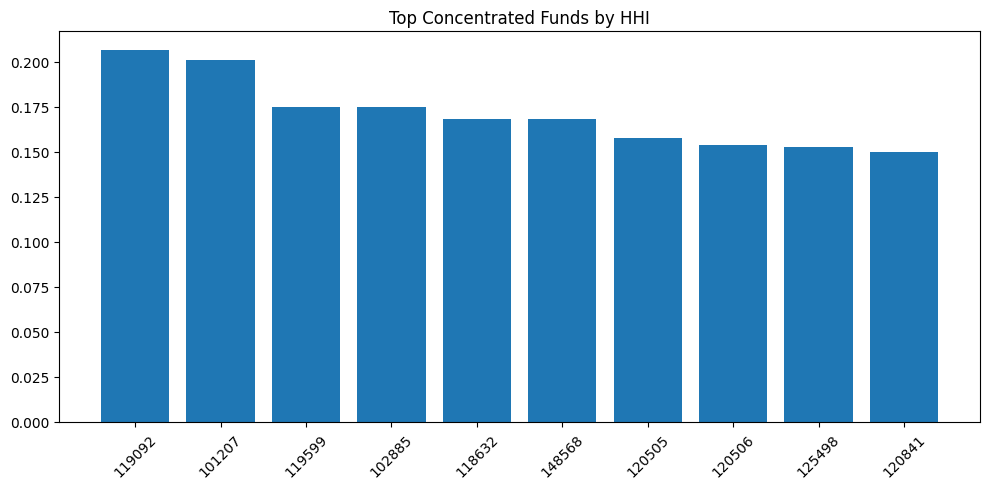

In [41]:
top_hhi = (
    sector_hhi
    .sort_values(
        "hhi",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top_hhi["amfi_code"].astype(str),
    top_hhi["hhi"]
)

plt.title(
    "Top Concentrated Funds by HHI"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sector_hhi_chart.png"
)

plt.show()

# Advanced Analytics Summary
Key Insights
1. Downside Risk Analysis (VaR & CVaR)

The VaR and CVaR analysis identified funds with the highest potential downside risk during adverse market conditions. Funds with more negative VaR and CVaR values are exposed to larger losses during extreme market movements. These funds may be suitable only for investors with higher risk tolerance.

2. Rolling Sharpe Ratio Performance

The 90-Day Rolling Sharpe Ratio analysis showed that risk-adjusted performance varies significantly over time. Among the selected funds, some consistently maintained Sharpe Ratios above 2, indicating strong risk-adjusted returns, while others experienced periods of negative Sharpe Ratios during market corrections. The chart highlights how fund performance changes across different market cycles.

3. Investor Cohort Behaviour

Investor cohorts were created based on the year of first investment. The analysis revealed differences in average SIP amounts and total investment values between cohorts. Recent cohorts demonstrated growing participation, reflecting increasing investor interest in mutual fund investments.

4. SIP Continuity Analysis

SIP continuity analysis identified investors with irregular investment behaviour. Investors whose average transaction gap exceeded 35 days were classified as At Risk. These investors may require targeted engagement and retention strategies to improve SIP continuation rates and reduce investor churn.

5. Portfolio Concentration Risk (HHI)

Sector concentration was measured using the Herfindahl-Hirschman Index (HHI). Funds with higher HHI values were found to be concentrated in fewer sectors, increasing exposure to sector-specific risks. Conversely, funds with lower HHI values demonstrated better diversification and potentially lower concentration risk.

Business Recommendations
Prefer funds with higher Sharpe Ratios and moderate risk levels for long-term investors.
Monitor funds with extreme VaR and CVaR values during volatile market conditions.
Implement investor retention campaigns for At-Risk SIP investors.
Encourage diversification by avoiding highly concentrated portfolios with elevated HHI values.
Use cohort-level insights to design targeted investment products and marketing campaigns for different investor segments.